In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pymysql

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
ACTIVE_SOLDIER_PATH = "../raw/현역병_입영현황.csv"
ENLISTED_SOLDIER_PATH = "../raw/모집병_입영현황__군별.csv"
ACTIVE_SOLDIER_AGE_PATH = "../raw/현역병_입영현황__연령별.csv"

df_active_soldier = pd.read_csv(ACTIVE_SOLDIER_PATH, encoding="cp949")
df_enlisted_soldier = pd.read_csv(ENLISTED_SOLDIER_PATH, encoding="cp949")
df_active_soldier_age = pd.read_csv(ACTIVE_SOLDIER_AGE_PATH, encoding="cp949")

df_active_soldier = df_active_soldier.set_index("군별")
df_enlisted_soldier = df_enlisted_soldier.set_index("군별")
# df_active_soldier_age = df_active_soldier.set_index("연령별")

In [3]:
df_active_soldier.head()

,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
군별,,,,,,,,,,,,,,,,
육군,134643,147695,150827,139842,125536,137643,111971,120395,109458,101733,107269,109371,97649,90358,85324,83393


In [4]:
df_enlisted_soldier.head()

,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
군별,,,,,,,,,,,,,,,,
육군,86283,84519,91368,94824,89459,95846,97858,102220,80571,84433,79176,87514,78900,60680,64379,61201
해군,8795,8716,9708,9863,9001,9758,8694,8789,7991,8050,8643,8871,7764,7060,7455,10628
해병대,11235,12066,12458,12686,12849,13127,12932,11491,11156,11380,11524,12399,12863,10426,10140,11944
공군,16944,15768,17608,17109,19326,17918,18022,18308,17939,16921,17450,17991,18578,17677,19890,18700


In [5]:
df_active_soldier_age

,연령별,2008,2008.1,2009,2009.1,2010,2010.1,2011,2011.1,2012,...,2020,2020.1,2021,2021.1,2022,2022.1,2023,2023.1,2024,2024.1
0,연령별,인원수 (명),비율 (%),인원수 (명),비율 (%),인원수 (명),비율 (%),인원수 (명),비율 (%),인원수 (명),...,인원수 (명),비율 (%),인원수 (명),비율 (%),인원수 (명),비율 (%),인원수 (명),비율 (%),인원수 (명),비율 (%)
1,계,132484,100.0,134643,100.0,147695,100.0,150827,100.0,139842,...,109371,100.0,97649,100.0,90358,100.0,85324,100.0,83393,100.0
2,19세,14385,10.9,25297,18.8,33553,22.7,32976,21.8,24478,...,3755,3.4,1902,1.9,4942,5.5,4697,5.5,5824,7.0
3,20세,-,-,-,-,-,-,-,-,-,...,70062,64.1,61637,63.1,56076,62.1,54382,63.7,50046,60.0
4,21세,-,-,-,-,-,-,-,-,-,...,21482,19.6,21096,21.6,16882,18.7,14853,17.4,16251,19.5
5,22세,-,-,-,-,-,-,-,-,-,...,6442,5.9,5984,6.1,5662,6.3,4576,5.4,4696,5.6
6,23세,-,-,-,-,-,-,-,-,-,...,2989,2.7,2735,2.8,2566,2.8,2507,2.9,2321,2.8
7,24세,-,-,-,-,-,-,-,-,-,...,1688,1.5,1479,1.5,1463,1.6,1501,1.8,1445,1.7
8,25세이상,-,-,-,-,-,-,-,-,-,...,2953,2.7,2816,2.9,2767,3.1,2808,3.3,2810,3.4
9,20-22세,111867,84.4,103451,76.8,107826,73.0,112029,74.3,109978,...,-,-,-,-,-,-,-,-,-,-


In [6]:
df_soldier = df_active_soldier.add(df_enlisted_soldier, fill_value=0)

df_soldier.T

군별,공군,육군,해군,해병대
2009,16944.0,220926.0,8795.0,11235.0
2010,15768.0,232214.0,8716.0,12066.0
2011,17608.0,242195.0,9708.0,12458.0
2012,17109.0,234666.0,9863.0,12686.0
2013,19326.0,214995.0,9001.0,12849.0
2014,17918.0,233489.0,9758.0,13127.0
2015,18022.0,209829.0,8694.0,12932.0
2016,18308.0,222615.0,8789.0,11491.0
2017,17939.0,190029.0,7991.0,11156.0
2018,16921.0,186166.0,8050.0,11380.0


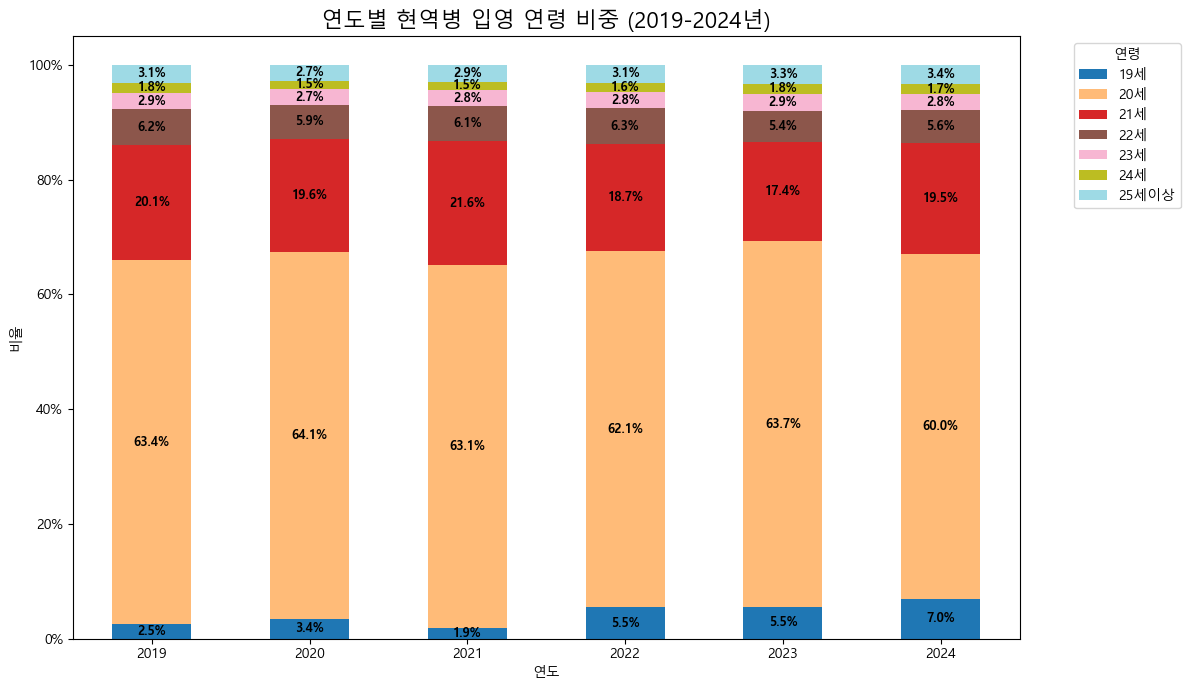

In [7]:
years_all = [col for col in df_active_soldier_age.columns if not col.endswith('.1') and col != '연령별']
years_2019_plus = [y for y in years_all if int(y) >= 2019]
df_data = df_active_soldier_age.iloc[2:].copy()
df_data = df_data.set_index('연령별')

df_data = df_active_soldier_age.iloc[2:].copy()
df_data = df_data.set_index('연령별')

# 4. 인원수 데이터만 발라내기 (0, 2, 4... 인덱스가 인원수)
df_counts = df_data.iloc[:, 0::2]
df_counts.columns = years_all # 일단 전체 연도를 입히고

# ★ 여기서 2019년 이후 컬럼만 선택 ★
df_counts = df_counts[years_2019_plus] 

# 5. 데이터 클리닝 (최신 Pandas map 사용)
def clean_val(x):
    if pd.isna(x) or x == '-':
        return 0.0
    return float(str(x).replace(',', ''))

df_counts = df_counts.map(clean_val)

# 6. 비중 계산 및 '전부 0인 행' 제거 (그래프 깔끔하게)
# 2019년 이후로는 20-22세 같은 뭉텅이 행이 0일 것이므로 제거해줍니다.
df_counts = df_counts[df_counts.sum(axis=1) > 0]
df_ratio = df_counts.div(df_counts.sum(axis=0), axis=1)

ax = df_ratio.T.plot(kind='bar', stacked=True, colormap='tab20', figsize=(12, 7))

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    #if height > 0.02:
    x, y = p.get_xy() 
    ax.text(x + width/2, 
            y + height/2, 
            f'{height*100:.1f}%', 
            ha='center', 
            va='center',
            fontsize=9,
            color='black',
            fontweight='bold')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.title("연도별 현역병 입영 연령 비중 (2019-2024년)", fontsize=16)
plt.ylabel("비율")
plt.xlabel("연도")
plt.legend(title="연령", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("연도별 현역병 입영 연령 비중.png")
plt.show()

In [8]:
enlistment_weights = df_ratio.mean(axis=1)

enlistment_weights = enlistment_weights / enlistment_weights.sum()

# 추후 이걸 sql로 넣을 예정

print(enlistment_weights)

연령별
19세      0.043081
20세      0.627356
21세      0.194951
22세      0.059142
23세      0.028271
24세      0.016587
25세이상    0.030612
dtype: float64


In [9]:
conn = pymysql.connect(host='localhost', user='root', password='123456', db='projectdb', charset='utf8')

target_year_limit = 2042

try:
    cursor = conn.cursor()

    cursor.execute("SELECT * FROM poptbl WHERE year = 2024")
    row_2024 = cursor.fetchone()
    
    cursor.execute("DESC poptbl")
    col_names = [col[0] for col in cursor.fetchall()]
    
    current_data = dict(zip(col_names, row_2024))

    for year in range(2025, target_year_limit + 1):
        new_row_data = {'year': year}

        for i in range(1, 31):
            prev_age_col = str(i-1)
            curr_age_col = str(i)
            
            if prev_age_col in col_names and curr_age_col in col_names:
                new_row_data[curr_age_col] = current_data.get(prev_age_col, 0)

        quoted_cols = [f"`{c}`" for c in new_row_data.keys()]
        columns_sql = ', '.join(quoted_cols)
        placeholders = ', '.join(['%s'] * len(new_row_data))
        
        insert_sql = f"INSERT INTO poptbl ({columns_sql}) VALUES ({placeholders})"
        cursor.execute(insert_sql, list(new_row_data.values()))

        current_data = new_row_data.copy()

    conn.commit()
    print("성공")

except Exception as e:
    print("오류 발생:", e)
    conn.rollback()

finally:
    cursor.close()
    conn.close()

성공


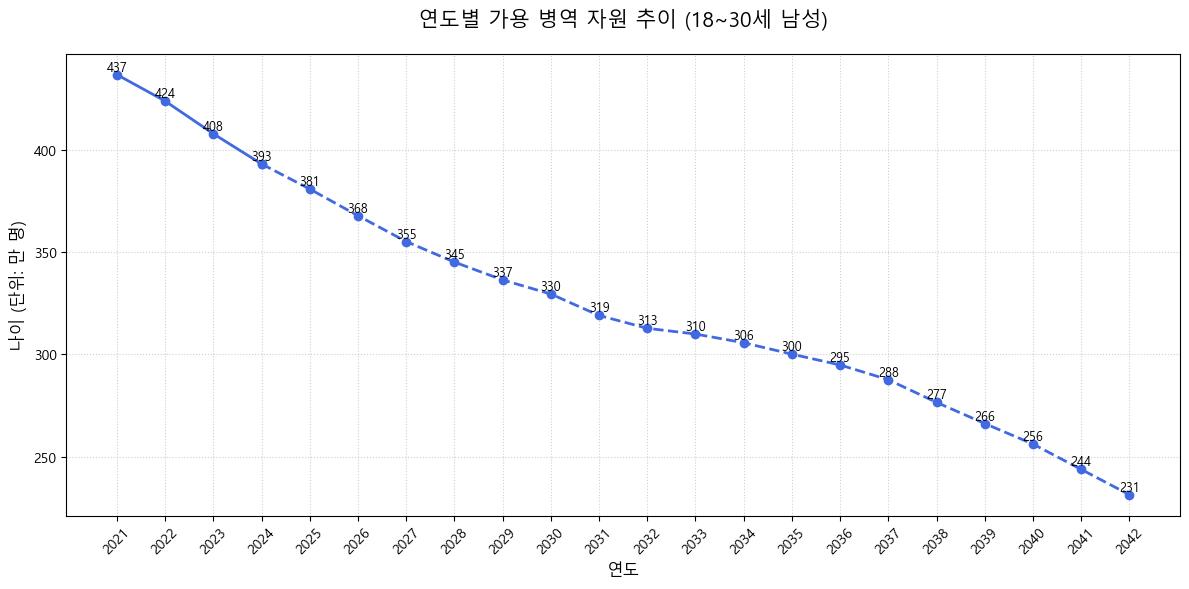

In [10]:
conn = pymysql.connect(host='localhost', user='root', password='123456', db='projectdb', charset='utf8')

try:
    # 2. 18세부터 30세까지 합산 쿼리
    age_columns = [f"`{age}`" for age in range(18, 31)]
    sum_query = " + ".join(age_columns)
    sql = f"SELECT year, ({sum_query}) as total_available FROM poptbl ORDER BY year"
    
    # 3. 데이터 로드 및 단위 변환 (명 -> 만 명)
    cursor = conn.cursor()
    cursor.execute(sql)
    data = cursor.fetchall()
    df = pd.DataFrame(data, columns=['year', 'total_available'])
    
    # 단위를 '만 명'으로 나누기
    df['total_man'] = df['total_available'] / 10000

    # 4. 그래프 그리기
    plt.figure(figsize=(12, 6))

    # 실측 데이터 (2024년까지) - 파란색 실선
    actual_df = df[df['year'] <= 2024]
    plt.plot(actual_df['year'], actual_df['total_man'], 
             marker='o', linestyle='-', color='royalblue', linewidth=2, label='Actual')

    # 예측 데이터 (2024년부터) - 파란색 점선 (연결을 위해 2024 포함)
    predict_df = df[df['year'] >= 2024]
    plt.plot(predict_df['year'], predict_df['total_man'], 
             marker='o', linestyle='--', color='royalblue', linewidth=2, label='Predicted')

    # 5. 그래프 꾸미기
    plt.title('연도별 가용 병역 자원 추이 (18~30세 남성)', fontsize=15, pad=20)
    plt.xlabel('연도', fontsize=12)
    plt.ylabel('나이 (단위: 만 명)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)

    for i, row in df.iterrows():
        plt.text(row['year'], row['total_man'] + 0.5, # x축, y축(약간 위로)
                 f'{row["total_man"]:.0f}',           # 소수점 한자리까지
                 ha='center', va='bottom', fontsize=9)
    
    # X축 연도 간격 조정
    plt.xticks(df['year'], rotation=45)

    plt.tight_layout()
    plt.savefig("연도별 가용 병력 자원 추이 (18~30세 남성).png")
    plt.show()

except Exception as e:
    print("오류 발생:", e)

finally:
    conn.close()

In [37]:
conn = pymysql.connect(host='localhost', user='root', password='123456', db='projectdb', charset='utf8')
cursor = conn.cursor()

RATE = 0.864 

try:
    # 1. 기초 데이터 로드
    age_rates = pd.read_sql("SELECT * FROM agetbl ORDER BY age", conn).set_index('age')['rate'].to_dict()
    branch_info = pd.read_sql("SELECT * FROM inputtbl", conn).set_index('name')
    df_pop = pd.read_sql("SELECT * FROM poptbl", conn)

    # 2. 누적 입대 확률 계산 (Pre-calculation)
    # cum_rates[22] = 19세~22세까지 입대할 확률의 총합
    cum_rates = {}
    current_sum = 0
    for a in range(19, 31):
        current_sum += age_rates.get(a, 0)
        cum_rates[a] = current_sum

    for idx, row in df_pop.iterrows():
        year = int(row['year'])
        for age in range(19, 31):
            total_pop = int(row[str(age)] * RATE)

            # (A) 당해 신규 입대자
            new_enlist = int(total_pop * age_rates.get(age, 0))
            
            # (B) 복무 중인 인원 (세현님 공식: 가중치 적용)
            # 작년 데이터가 없을 경우를 대비해 현재 인구를 코호트 크기로 가정
            serving = {}
            for branch, info in branch_info.iterrows():
                # 올해 입대분(가중치) + 작년 입대분(가중치)
                # (정밀도를 위해 작년 나이 인구를 가져오지만, 없을 경우 현재 인구 사용)
                this_enlist_ratio = age_rates.get(age, 0) * info['rate']
                prev_enlist_ratio = age_rates.get(age-1, 0) * info['rate']
                
                serving[branch] = int(total_pop * (this_enlist_ratio + prev_enlist_ratio) * (info['month'] / 24))

            total_serving = sum(serving.values())

            # (C) ★ 전역자(Discharged) 계산: (해당 나이까지의 누적 입대자) - (현재 복무자)
            # cum_rates[age]는 '지금까지 입대했거나 입대한 적 있는' 비율
            total_ever_enlisted = int(total_pop * cum_rates[age])
            discharged = total_ever_enlisted - total_serving
            
            # 만약 계산상 마이너스가 나오면 0으로 보정 (초기 나이대 오차 방지)
            discharged = max(0, discharged)

            # (D) 미필자(Unlisted) 계산: 전체 - (현재 복무 + 전역)
            unlisted = total_pop - (total_serving + discharged)
            unlisted = max(0, unlisted)

            # (E) DB 입력
            sql = """
            INSERT INTO militarytbl 
            (year, age, total_pop, new_enlist, total_serving, discharged, unlisted)
            VALUES (%s, %s, %s, %s, %s, %s, %s)
            ON DUPLICATE KEY UPDATE 
                total_pop=VALUES(total_pop), 
                total_serving=VALUES(total_serving),
                discharged=VALUES(discharged),
                unlisted=VALUES(unlisted);
            """
            cursor.execute(sql, (
                year, age, total_pop, new_enlist, 
                total_serving, discharged, unlisted
            ))
            
    conn.commit()
    print("--- 역산 시뮬레이션 완료: 전역자/미필자 데이터가 정교화되었습니다 ---")

except Exception as e:
    print(f"오류 발생: {e}")
    conn.rollback()
finally:
    conn.close()

--- 역산 시뮬레이션 완료: 전역자/미필자 데이터가 정교화되었습니다 ---


--- [국방 인력 유지 시뮬레이션 시스템] ---


유지 목표 병사 수 (간부 제외, 예: 300000):  310000


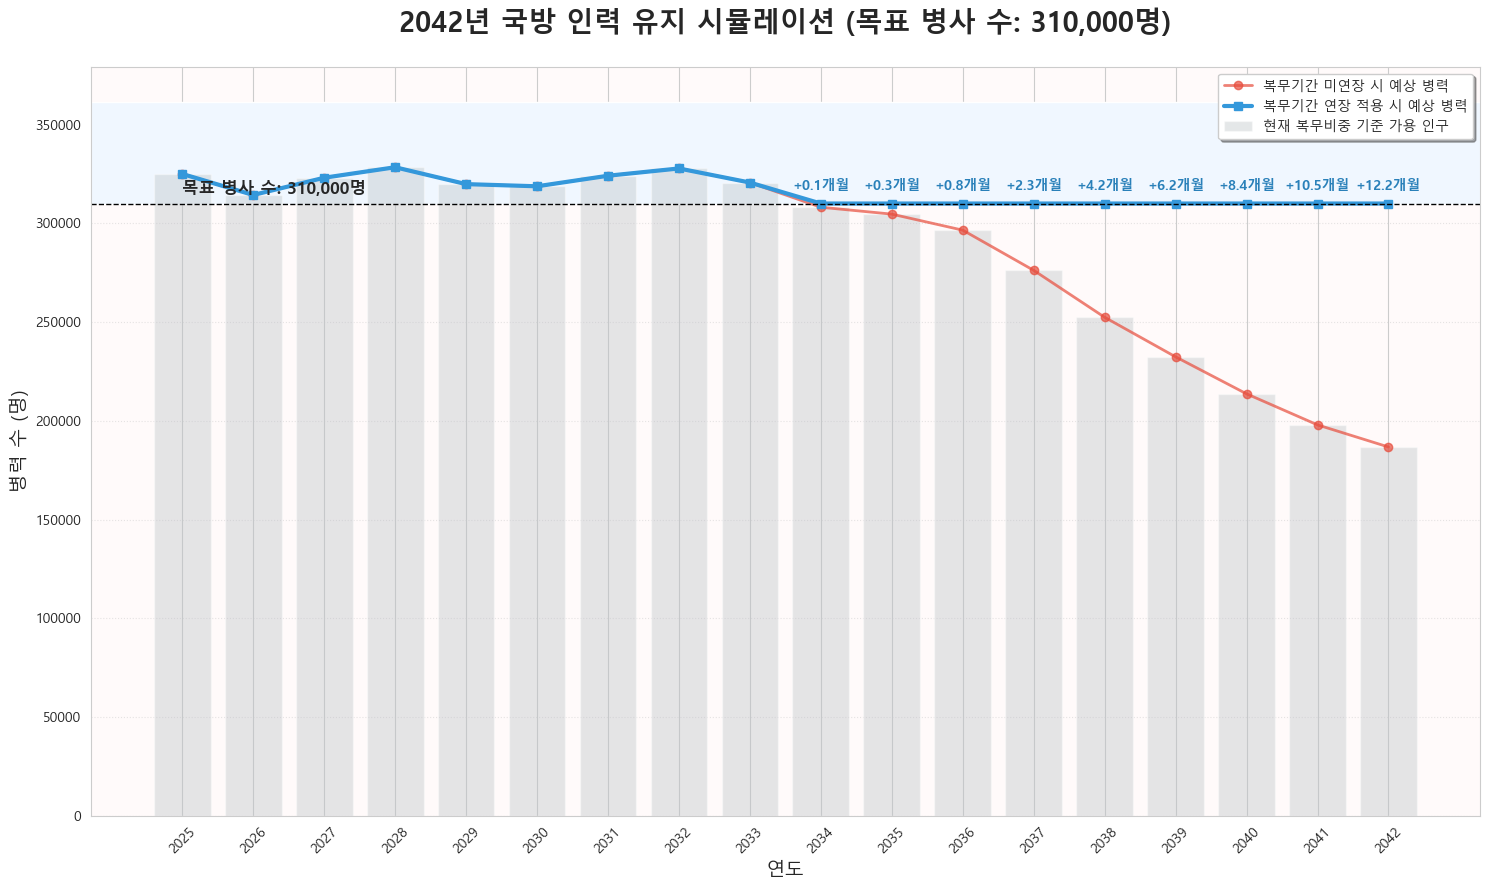


연도     | 가용인구       | 추가 연장 개월   | 육군 예상 복무
-------------------------------------------------------
2025     |    421,203 | 연장 불필요       | 18.0개월
2026     |    407,395 | 연장 불필요       | 18.0개월
2027     |    418,719 | 연장 불필요       | 18.0개월
2028     |    425,604 | 연장 불필요       | 18.0개월
2029     |    414,528 | 연장 불필요       | 18.0개월
2030     |    413,107 | 연장 불필요       | 18.0개월
2031     |    420,033 | 연장 불필요       | 18.0개월
2032     |    424,810 | 연장 불필요       | 18.0개월
2033     |    415,561 | 연장 불필요       | 18.0개월
2034     |    399,364 | +0.1개월       | 18.1개월
2035     |    394,839 | +0.3개월       | 18.3개월
2036     |    384,315 | +0.8개월       | 18.8개월
2037     |    357,940 | +2.3개월       | 20.3개월
2038     |    327,142 | +4.2개월       | 22.2개월
2039     |    301,173 | +6.2개월       | 24.2개월
2040     |    276,906 | +8.4개월       | 26.4개월
2041     |    256,530 | +10.5개월      | 28.5개월
2042     |    242,021 | +12.2개월      | 30.2개월


In [50]:
import pymysql
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import warnings

# 1. 한글 설정
font_path = "C:/Windows/Fonts/malgun.ttf"
if not os.path.exists(font_path): font_path = "C:/Windows/Fonts/gulim.ttc"
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rc('axes', unicode_minus=False)
warnings.filterwarnings('ignore')

conn = pymysql.connect(host='localhost', user='root', password='123456', db='projectdb', charset='utf8')

try:
    print("--- [국방 인력 유지 시뮬레이션 시스템] ---")
    target_total = int(input("유지 목표 병사 수 (간부 제외, 예: 300000): "))

    enlist_data = {'육': 144594, '해': 10628, '공': 18700, '해병': 11944}
    service_months = {'육': 18, '해': 20, '공': 22, '해병': 18}
    total_enlist = sum(enlist_data.values())

    weighted_avg_m = sum([(enlist_data[k] / total_enlist) * service_months[k] for k in enlist_data])
    current_ratio = weighted_avg_m / 24

    df_raw = pd.read_sql("SELECT year, SUM(new_enlist) as raw FROM militarytbl GROUP BY year ORDER BY year", conn)
    df_raw['two_year_pool'] = (df_raw['raw']) + (df_raw['raw']).shift(1)
    df = df_raw[df_raw['year'] >= 2025].copy().fillna(0)

    years = df['year'].astype(int).tolist()
    
    current_line = [] 
    extended_line = []
    extension_reports = []

    for p in df['two_year_pool']:

        c_force = p * (weighted_avg_m / 24)
        current_line.append(c_force)

        req_m = (target_total * 24) / p
        x_months = max(0, req_m - weighted_avg_m)
        
        e_force = p * (max(weighted_avg_m, req_m) / 24)
        extended_line.append(e_force)
        extension_reports.append(x_months)

    fig, ax = plt.subplots(figsize=(15, 9))

    ax.set_facecolor('#fffafa')
    ax.axhspan(target_total, max(extended_line)*1.1, facecolor='#f0f7ff', alpha=1)

    bars = plt.bar(years, [p * current_ratio for p in df['two_year_pool']], color='#bdc3c7', alpha=0.4, label='현재 복무비중 기준 가용 인구')
    plt.plot(years, current_line, color='#e74c3c', marker='o', linewidth=2, label='복무기간 미연장 시 예상 병력', alpha=0.7)
    line_ext = plt.plot(years, extended_line, color='#3498db', marker='s', linewidth=3, label='복무기간 연장 적용 시 예상 병력')

    for i, txt in enumerate(extension_reports):
        if txt > 0:
            plt.annotate(f'+{txt:.1f}개월', 
                         (years[i], extended_line[i]), 
                         textcoords="offset points", 
                         xytext=(0,10), 
                         ha='center', 
                         fontsize=10, 
                         fontweight='bold', 
                         color='#2980b9')

    # 목표선 표시
    plt.axhline(y=target_total, color='black', linestyle='--', linewidth=1)
    plt.text(years[0], target_total + 5000, f'목표 병사 수: {target_total:,}명', fontsize=12, fontweight='bold')

    plt.title(f'2042년 국방 인력 유지 시뮬레이션 (목표 병사 수: {target_total:,}명)', fontsize=20, fontweight='bold', pad=25)
    plt.ylabel('병력 수 (명)', fontsize=14)
    plt.xlabel('연도', fontsize=14)
    plt.xticks(years, rotation=45)
    plt.gca().ticklabel_format(style='plain', axis='y')
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.legend(loc='upper right', shadow=True)
    plt.tight_layout()

    plt.savefig(f'2042년 국방 인력 유지 시뮬레이션 (목표 병사 수 {target_total}명).png')
    plt.show()

    # --- 텍스트 리포트 출력 ---
    print(f"\n{'='*55}")
    print(f"{'연도':<6} | {'가용인구':<10} | {'추가 연장 개월':<10} | {'육군 예상 복무'}")
    print(f"{'-'*55}")
    
    for i in range(len(years)):
        ext = extension_reports[i]
        status = f"+{ext:.1f}개월" if ext > 0 else "연장 불필요"
        army_service = 18 + ext
        print(f"{years[i]:<8} | {int(df['two_year_pool'].iloc[i]):>10,} | {status:<12} | {army_service:.1f}개월")
    print(f"{'='*55}")

except Exception as e:
    print(f"오류 발생: {e}")
finally:
    conn.close()